<p style="text-align:right;">Mario Stanke, University of Greifswald, Germany</p>

# Solution to Exercise Set 2 - 2 - Different Activation Functions in a Regression Neural Network

This is a copy of notebook ```nn-regr.ipynb``` for solving the following exercises:

  0. Run all cells.  
   
  1. Replace the sigmoid activation function with the **ReLU** function and observe how the shape of the predicted curve changes. *Revert back* afterwards to the *sigmoid* activation function.
   
  2. **Shift** the simulated data on the **x**-axis by **+50**.  
    2.1. **For the mathematically inclined:**   
    Let $x' := x + 50$. Show or argue that it theoretically does not matter if you shift (use input $x'$) or not (use $x$):  *For any neural net $f(x)$ there is a neural net $f'(x')$ such that $f'(x') = f(x)$*. You may assume that $n=1$.  
    2.2. **Go to ADD YOUR CODE HERE** and follow the instructions. Run all cells. What happens to the goodness of the fit? Do you have an explanation? Tip: Compute the net activations of the first layer manually right before training starts.

## Generate an Artificial Dataset

In [ ]:
# import libraries
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input

2025-03-08 20:11:18.435752: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-08 20:11:18.435938: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-08 20:11:18.438323: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-08 20:11:18.473872: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-08 20:11:19.078907: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

In [2]:
def f(x):
    '''A simple one-dimensional function with a few extrema'''
    return np.sin(15 * x) + 9 * x - 9 * x**2

#### Simulate $(x, y)$ pairs as artificial data set

In [3]:
np.random.seed(1)
m = 100 # number of data points (examples)
x = np.linspace(0, 1, m) # equidistant in [0,1] (both boundaries included)
y_theoretical = f(x)     # the points on the curve
# ADD YOUR CODE HERE to shift x by +50, 1 line

# YOUR CODE ENDS
sigma = 0.1
y = y_theoretical + sigma * np.random.randn(m) # observations have noise (normal with mean 0 and variance sigma^2 = 0.01)

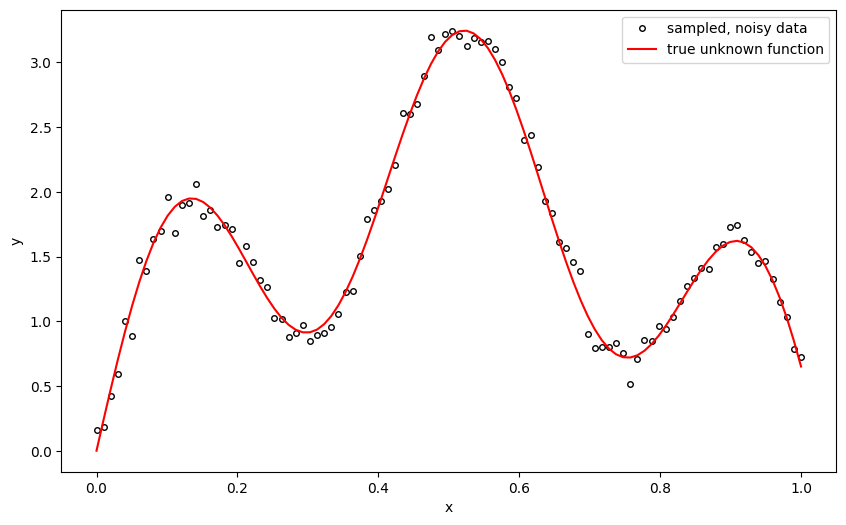

In [4]:
def plot_curve():
    fig, ax = plt.subplots(figsize = (10, 6))
    ax.plot(x, y, 'ko', fillstyle = 'none', markersize = 4, label = "sampled, noisy data") # ko: blac(k) circle
    ax.plot(x, y_theoretical, 'r', label = "true unknown function")
    plt.xlabel("x")
    plt.ylabel("y")
    return ax

ax = plot_curve()
ax.legend();

## Create Neural Network Model  
We will use [```tf.keras```](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/keras), a high-level approach to neural network design and learning. The NN shall have 2 hidden layers with 8 neurons each. As activation functions we chose the logistic sigmoid function $\sigma$.

<img src="../nn8-8.png" alt="network architecture" width="500"/>

In [5]:
tf.random.set_seed(1) # so we all get the same pseudorandom results

# a neural network is a stack of layers, in keras called "Sequential" model
model = tf.keras.models.Sequential() # so far the stack is empty, 0 layers
model.add(Input(shape=(1,))) # implicitly specifies the input dimension

# add neural network layers one by one
# Dense is a fully connected layer, parametrized by a matrix of shape (input_units, output_units).
# The first number given in Dense is the number of output units, the number of input units is implicit.
# By default use_bias=True which adds output_units parameters for each layer
# REPLACE THE ACTIVATION FUNCTION HERE with tf.nn.relu
model.add(Dense(8, activation = tf.nn.sigmoid)) # input dimension only required for first layer
model.add(Dense(8, activation = tf.nn.sigmoid))
# YOUR CHANGES END HERE
model.add(Dense(1))

model.summary()     # summarizes layers and parameters
Theta = model.get_weights() # a look under the 'hood' for teaching purposes
print(Theta)

2025-03-08 20:11:19.958590: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-03-08 20:11:19.958881: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97 (776.00 B)

 Trainable params: 97 (776.00 B)

 Non-trainable params: 0 (0.00 B)

[array([[-0.3370496 , -0.24552086, -0.23121892, -0.67183635,  0.42651439,
        -0.55185337, -0.6707455 ,  0.77214745]]), array([0., 0., 0., 0., 0., 0., 0., 0.]), array([[ 0.07526745, -0.06484745,  0.47310357, -0.18889662, -0.30399616,
        -0.49414115,  0.27413727, -0.21760289],
       [ 0.57863173,  0.26607888, -0.01954178, -0.32759998, -0.34955539,
         0.32783195, -0.00373799,  0.34519687],
       [ 0.07593034, -0.45967525,  0.55917277,  0.16140997, -0.03111397,
        -0.14257488, -0.14588085,  0.44594011],
       [-0.03415741, -0.03413197, -0.438207  ,  0.01370839,  0.23130961,
        -0.54321466,  0.43943869, -0.22606492],
       [ 0.53570074,  0.00382062,  0.23647559, -0.20065661,  0.20519827,
        -0.14851774,  0.06825993, -0.57018796],
       [ 0.46467948, -0.40973992, -0.09985153,  0.03672209,  0.01058982,
         0.16909023, -0.01390104, -0.48185223],
       [-0.19546931, -0.47689679,  0.12606274,  0.16415154, -0.22802429,
        -0.58095467,  0.35198279,  0

## Explanation, why the training with the x-shift by +50 fails
To see this we will manually compute the **activations of the first layer right after the random initialization** of the model parameters.

In [6]:
Theta0 = Theta[0] # weights of the first layer, shape =(1,8)
bias0 = Theta[1] # biases of the first layer, shape = (8,) 

# compute net activations of first layer
# YOUR CODE HERE to compute the net activations of the first hidden layer, 1 line
z1 = np.zeros([x.shape[0], Theta0.shape[1]])
# YOUR CODE ENDS
print(z1.shape)

def sigmoid(z):
    """The logistic sigmoid function"""
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(x):
    """ The derivative of sigmoid"""
    return sigmoid(x) * (1-sigmoid(x))


print("z1\n", z1[0:5].round(3)) # print the net activations of the first layer for the first 5 examples
print("\na1\n", sigmoid(z1[0:5])) # # print the activations of the first layer for the first 5 examples
print("\nderivatives used in backprop:\n", sigmoid_deriv(z1[0:5]))


(100, 8)
z1
 [[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]

a1
 [[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
 [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]]

derivatives used in backprop:
 [[0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25]]


**Observation:** Almost all net activations of the first layer have a large absolute value. For large absolute value the logistic sigmoid function has a derivative very close to 0:

<img src="../activ-sigma.png" alt="sigmoid function" width="300"/>

Therefore, any small change to any weight of an edge of the first layer that goes into such a unit is very close to 0 or even vanishes numerically.

### Compile the model

In [7]:
# define the loss, optimization algorithm and prepare the model for gradient computation 
opti = tf.keras.optimizers.Adam(learning_rate = 0.05) # Adam is a popular method for stochastic gradient descent
model.compile(optimizer = opti, loss = 'mse') # mean squared error

### Train the parameters (learning)

In [ ]:
# execute the actual training 
history = model.fit(x, y, epochs=3000, verbose=0) # takes ~1m
# verbose = 1,2 gives more output

2025-03-08 20:11:20.657369: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:11:20.657461: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:11:20.657500: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:11:20.657557: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:11:20.657589: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:11:20.683399: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:11:20.683534: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:11:20.683566: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:11:20.683664: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:11:20.683693: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE


### Examine the learning progress

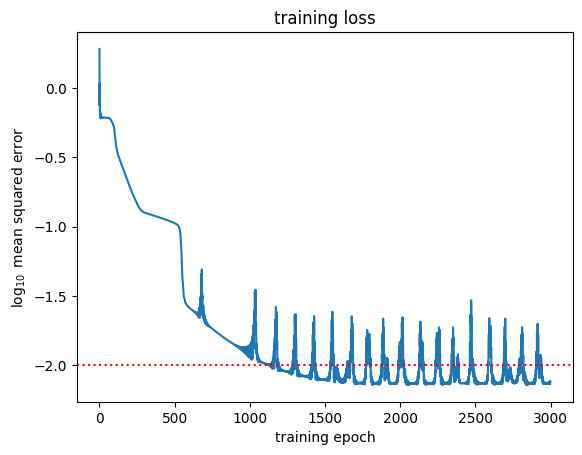

In [9]:
plt.plot(np.log10(history.history["loss"])); # one mse value per epoch
plt.title("training loss")
plt.xlabel("training epoch")
plt.ylabel(r"$\log_{10}$ mean squared error");
plt.axhline(y = np.log10(sigma**2), color = "red", linestyle = ":");

Observe that with our choice for the measurement noise the theoretical optimum for the mean squared error *on new data* is $10^{-2}$ (red dotted line).
### Use the model for predictions

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


2025-03-08 20:12:12.355953: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:12:12.356111: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:12:12.356142: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:12:12.356266: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:12:12.356294: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:12:12.358338: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:12:12.358479: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:12:12.358509: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:12:12.358637: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:12:12.358664: W tensorflow/core/util/util.cc:161] Not handling type DT_DOUBLE
2025-03-08 20:12:12.380160: W tensorflow/core/util/util.cc:161] Not handling typ

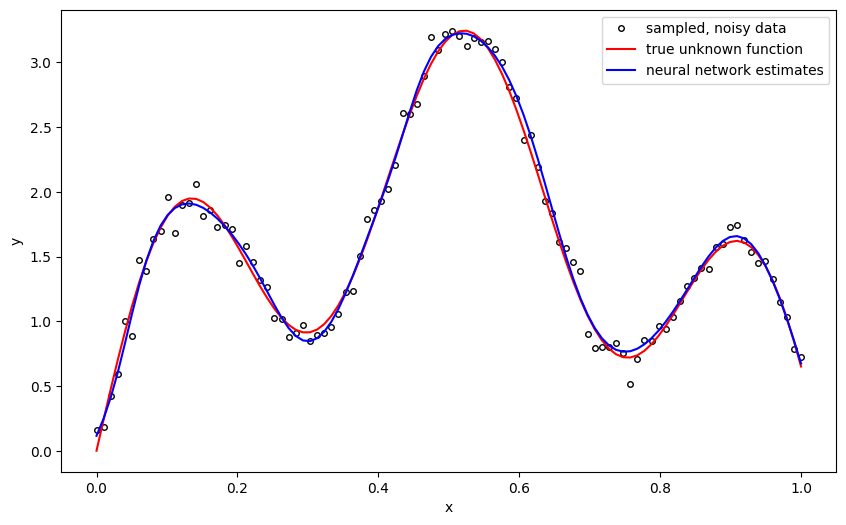

In [10]:
x_input = x.reshape((-1, 1)) # make x a matrix (with 1 column) as expected by predict
y_pred = model.predict(x_input)

ax = plot_curve()
ax.plot(x, y_pred, 'b', label = "neural network estimates") # (b)lue
ax.legend();